In [37]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
from datasets import load_dataset

# Loading dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [51]:
df_country = df[df['job_country'] == 'United States']

In [53]:
# Exploding Skills

df_skills = df_country.explode('job_skills')


In [40]:
df_skills_count = df_skills.groupby(['job_skills','job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name='skills_count')
df_skills_count.sort_values(by='skills_count', ascending=False, inplace=True)
df_skills_count

,job_skills,job_title_short,skills_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
1785,vue.js,Business Analyst,1
60,arch,Business Analyst,1
71,asana,Machine Learning Engineer,1
968,no-sql,Machine Learning Engineer,1


In [41]:
df_total_jobs = df_country['job_title_short'].value_counts().reset_index(name='jobs_total')
df_total_jobs

,job_title_short,jobs_total
0,Data Analyst,67816
1,Data Scientist,58830
2,Data Engineer,35080
3,Senior Data Scientist,12946
4,Senior Data Analyst,11791
5,Senior Data Engineer,9289
6,Business Analyst,7382
7,Software Engineer,1814
8,Machine Learning Engineer,921
9,Cloud Engineer,423


In [42]:
df_percent_skills = pd.merge(df_skills_count, df_total_jobs, how='left', on='job_title_short')
df_percent_skills['skills_percent'] = 100 * df_percent_skills['skills_count'] / df_percent_skills['jobs_total'] 
df_percent_skills

,job_skills,job_title_short,skills_count,jobs_total,skills_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


In [43]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3]) # Sorted here orders in alfabetical order
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

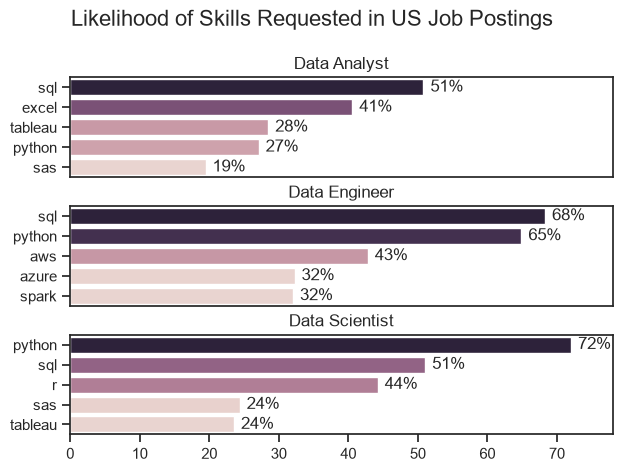

In [67]:
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
   df_plot = df_percent_skills[df_percent_skills['job_title_short'] == job_title].head(5)
   sns.barplot(data=df_plot, x='skills_percent', y='job_skills', ax=ax[i], hue='skills_count')
   ax[i].set_title(job_title)
   ax[i].set_xlabel('')
   ax[i].set_ylabel('')
   ax[i].legend().set_visible(False)
   ax[i].set_xlim(0,78)
   
   for n, v in enumerate(df_plot['skills_percent']):
      ax[i].text(v + 1, n, f'{v:.0f}%', va='center')
   
   if i != len(job_titles) - 1:
      ax[i].set_xticks([])

plt.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=16)
plt.tight_layout(h_pad=0.5)
plt.show()
